# Proyecto 1 — Analisis del rendimiento academico

**Dataset:** Students Performance in Exams (Kaggle)

Análisis exploratorio del desempeño de estudiantes en matemáticas, lectura y escritura, buscando patrones relacionados con el curso de preparación, el nivel educativo de los padres y otras variables demográficas.

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/StudentsPerformance.xls')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 2. Exploración inicial

**Número de registros y columnas**

In [49]:
df.shape

(1000, 8)

**Nombre de las variables**

In [50]:
df.columns.tolist()

['gender',
 'race/ethnicity',
 'parental level of education',
 'lunch',
 'test preparation course',
 'math score',
 'reading score',
 'writing score']

**Tipos de datos**

In [51]:
df.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

**Valores faltantes por columna**

In [52]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

**Registros duplicados**

df.duplicated().sum()

**Estadísticas descriptivas**

In [53]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 3. Limpieza y preprocesamiento

El dataset no presenta valores faltantes ni registros duplicados, por lo que la limpieza se limita a estandarizar los nombres de columnas (quitar espacios y el carácter `/`) para facilitar su manipulación en el código.

In [54]:
df.columns = [c.replace('/', '_').replace(' ', '_') for c in df.columns]
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 4. Variable `average_score`

Se crea como el promedio simple de las tres materias

In [55]:
df['average_score'] = df[['math_score', 'reading_score', 'writing_score']].mean(axis=1)
df[['math_score', 'reading_score', 'writing_score', 'average_score']].head()

,math_score,reading_score,writing_score,average_score
0,72,72,74,72.666667
1,69,90,88,82.333333
2,90,95,93,92.666667
3,47,57,44,49.333333
4,76,78,75,76.333333


## 5. Clasificación del rendimiento académico

Se definen tres categorías a partir de `average_score`, usando como referencia una escala de evaluación de 0 a 100 en la que 60 y 80 son los cortes habituales entre reprobado/aprobado y aprobado/sobresaliente:

| Categoría | Rango de `average_score` |
|---|---|
| Bajo | menor a 60 |
| Medio | de 60 a 80 |
| Alto | mayor a 80 |

Con esta escala, alrededor de una cuarta parte de los estudiantes cae en cada extremo (Bajo / Alto) y la mitad restante en Medio, lo cual es consistente con la distribución observada en las estadísticas descriptivas de la sección 2.

In [56]:
bins = [0, 60, 80, 100]
labels = ['Bajo', 'Medio', 'Alto']
df['performance_level'] = pd.cut(df['average_score'], bins=bins, labels=labels, include_lowest=True)
df[['average_score', 'performance_level']].head()

,average_score,performance_level
0,72.666667,Medio
1,82.333333,Alto
2,92.666667,Alto
3,49.333333,Bajo
4,76.333333,Medio


## 6. Análisis

### 6.1 ¿Cuál de las tres áreas tiene el promedio más alto?

In [57]:
df[['math_score', 'reading_score', 'writing_score']].mean().sort_values(ascending=False)

reading_score    69.169
writing_score    68.054
math_score       66.089
dtype: float64

**Respuesta:** la lectura (`reading_score`) es el área con el promedio más alto, seguida de escritura y, por último, matemáticas.

### 6.2 ¿Los estudiantes que realizaron el curso de preparación presentan mejores resultados?

In [58]:
df.groupby('test_preparation_course')['average_score'].agg(['mean', 'count'])

,mean,count
test_preparation_course,,
completed,72.669460,358
none,65.038941,642


**Respuesta:** sí. Quienes completaron el curso de preparación obtienen un `average_score` notablemente mayor que quienes no lo tomaron, lo que sugiere que el curso tiene un efecto positivo sobre el desempeño.

### 6.3 ¿Existen diferencias en el rendimiento según el nivel educativo de los padres?

In [59]:
df.groupby('parental_level_of_education')['average_score'].mean().sort_values(ascending=False)

parental_level_of_education
master's degree       73.598870
bachelor's degree     71.923729
associate's degree    69.569069
some college          68.476401
some high school      65.108007
high school           63.096939
Name: average_score, dtype: float64

**Respuesta:** sí existen diferencias. Los estudiantes cuyos padres tienen estudios de maestría o licenciatura presentan los promedios más altos, mientras que aquellos cuyos padres solo llegaron a la preparatoria ("some high school") presentan los promedios más bajos.

### 6.4 ¿Qué porcentaje de estudiantes cae en cada categoría de rendimiento?

In [60]:
(df['performance_level'].value_counts(normalize=True) * 100).round(1)

performance_level
Medio    51.3
Bajo     29.3
Alto     19.4
Name: proportion, dtype: float64

**Respuesta:** la mayoría de los estudiantes se ubica en la categoría Medio, con proporciones menores y relativamente similares entre Bajo y Alto.

### 6.5 ¿Qué grupos (`race/ethnicity`) presentan los promedios más altos y más bajos?

In [61]:
df.groupby('race_ethnicity')['average_score'].mean().sort_values(ascending=False)

race_ethnicity
group E    72.752381
group D    69.179389
group C    67.131661
group B    65.468421
group A    62.992509
Name: average_score, dtype: float64

**Respuesta:** el grupo E tiene el promedio más alto y el grupo A el más bajo, con una diferencia de varios puntos entre ambos extremos.

## 7. Visualizaciones

**Promedio general por curso de preparación**

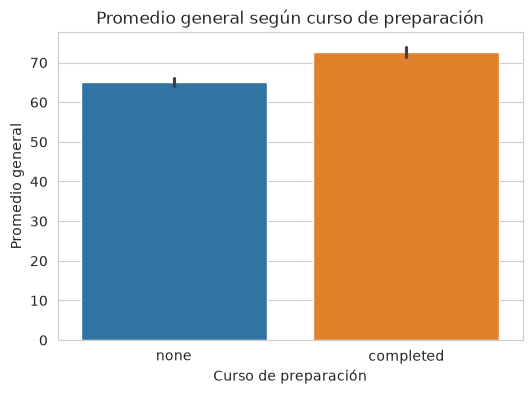

In [62]:
sns.set_style('whitegrid')
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='test_preparation_course', y='average_score', hue='test_preparation_course', legend=False)
plt.title('Promedio general según curso de preparación')
plt.xlabel('Curso de preparación')
plt.ylabel('Promedio general')
plt.show()

**Promedio general por nivel educativo de los padres**

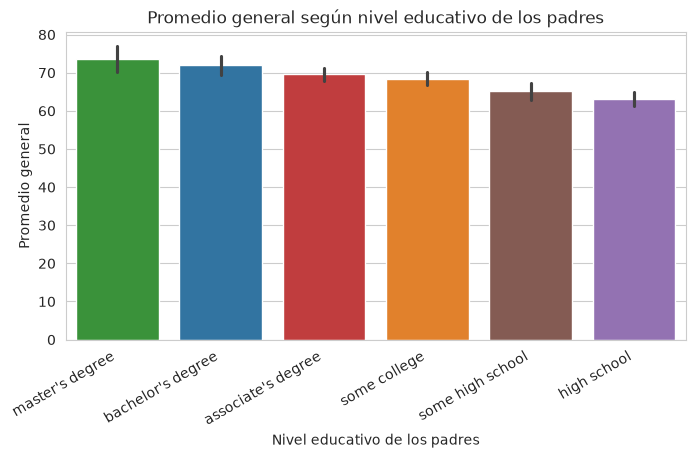

In [63]:
orden = df.groupby('parental_level_of_education')['average_score'].mean().sort_values(ascending=False).index
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='parental_level_of_education', y='average_score', order=orden, hue='parental_level_of_education', legend=False)
plt.title('Promedio general según nivel educativo de los padres')
plt.xlabel('Nivel educativo de los padres')
plt.ylabel('Promedio general')
plt.xticks(rotation=30, ha='right')
plt.show()

**Distribución de estudiantes por categoría de rendimiento**

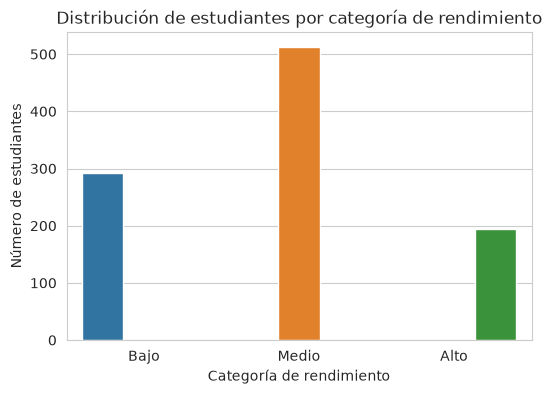

In [64]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='performance_level', order=['Bajo', 'Medio', 'Alto'], hue='performance_level', legend=False)
plt.title('Distribución de estudiantes por categoría de rendimiento')
plt.xlabel('Categoría de rendimiento')
plt.ylabel('Número de estudiantes')
plt.show()

**Distribución del promedio general por género**

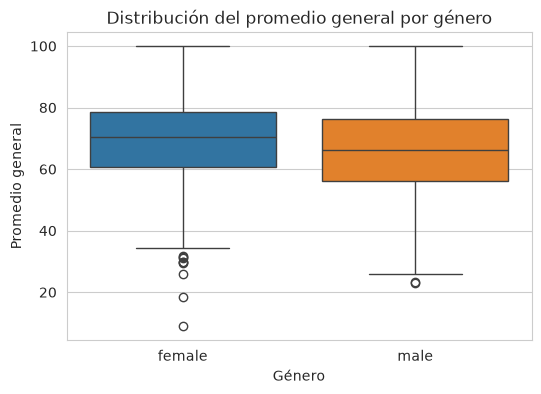

In [65]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='gender', y='average_score', hue='gender', legend=False)
plt.title('Distribución del promedio general por género')
plt.xlabel('Género')
plt.ylabel('Promedio general')
plt.show()

## 8. Conclusiones

- La lectura es el área con mejor desempeño promedio y matemáticas la más débil, lo cual es consistente entre los distintos subgrupos analizados.
- El curso de preparación para el examen está asociado a un mejor desempeño: los estudiantes que lo completaron obtienen en promedio varios puntos más que quienes no lo tomaron.
- El nivel educativo de los padres influye en el desempeño: a mayor nivel educativo de los padres, mayor tiende a ser el promedio de los estudiantes, con la maestría y la licenciatura a la cabeza y "some high school" en el último lugar.
- Al clasificar a los estudiantes en Bajo, Medio y Alto, la mayoría se concentra en la categoría Medio, lo que refleja una distribución relativamente centrada del promedio general.
- Existen diferencias notables entre los grupos étnicos reportados (`race/ethnicity`), con el grupo E mostrando el promedio más alto y el grupo A el más bajo.
- En conjunto, los resultados sugieren que factores externos al estudiante —preparación previa y contexto familiar— están relacionados con su desempeño académico, más allá de diferencias por género, que resultan menos marcadas.